##### **Подгрузка видео с калибровкой, вытаскивание нужных кадров**

|                        | Камера 1 | Камера 2 | Камера 3 |
|------------------------|----------|----------|----------|
|Ширина кадра            | 3840     | 3840     | 3840     |
|Высота кадра            | 2160     | 2160     | 2160     |
|Частота кадров,  кадр/с | 23,98    | 25,0     | 25,0     |

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image 

# Загрузка видео  
N_video = 3

if N_video == 1:
    # Начальный кадр 1848 (1:17), конечный 3504 (2:26) - выборка из 1656 кадров
    vidname = "Кам_1_GX017269.MP4"
    foldname = "cam1_calibrate_checkboard"
    frames_id = [1847 + i for i in range(1800)]
if N_video == 2:
    # Начальнй кадр 3575 (2:23), конечный 5150 (3:26) - выборка из 1575 кадров
    vidname = "Кам_2_GH010903.MP4"
    foldname = "cam2_calibrate_checkboard"
    frames_id = [3575 + i for i in range(1600)]
if N_video == 3:
    # Начальнй кадр 5050 (3:22), конечный 660 (4:24) - выборка из 1550 кадров
    vidname = "Кам_3_GH010108.MP4"
    foldname = "cam3_calibrate_checkboard"
    frames_id = [5050 + i for i in range(1600)]


cap = cv2.VideoCapture(f"local/videos/{vidname}")  
counter_figure, frames, ids = 0, [], []

In [77]:
for i in range(6000):
    add_info, frame = cap.read()                     # Чтение кадра 
    #if not add_info:                                 # Если кадры в видео закончились - остановить
    #    break 
    if add_info:
        if i in frames_id:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)   # Цветное изоб-е в чёрно-белое
            Image.fromarray(gray).save(f"local/videos/{foldname}/{i}.jpg")
            frames.append(gray)
            ids.append(i)
            counter_figure += 1
            if counter_figure == len(frames_id):         # Если кадры, которые нам нравятся, закончились - остановить
                break

**Совмещение шкал времени - калибровка светом**

In [ ]:
N_video = 1
vidname = "Кам_1_GX017269.MP4"
frames_id1 = [871, 898, 913, 936, 957, 976, 1083, 1106, 1157, 1174, 1204, 1223]
M, N, counter_figure = max(frames_id1), len(frames_id1), 0
fig, ax = plt.subplots(N, 3, figsize=(16,9*N/3))

cap = cv2.VideoCapture(f"local/videos/{vidname}") 
for i in range(1500):
    add_info, frame = cap.read()
    add_info = True
    if add_info and ((i+1) in frames_id1):
        ax[counter_figure][0].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][0].set_title(f"Кадр {i}")
    if add_info and (i in frames_id1):
        ax[counter_figure][1].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][1].set_title(f"Кадр {i}")
    if add_info and ((i-1) in frames_id1):
        ax[counter_figure][2].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][2].set_title(f"Кадр {i}")
        counter_figure += 1
    if (counter_figure == len(frames_id1)) or i > M+1:
        break

plt.show()

In [ ]:
N_video = 2
vidname = "Кам_2_GH010903.MP4"
frames_id2 = [808, 835, 852, 875, 897, 915, 1029, 1051, 1105, 1123, 1154, 1178]
M, N, counter_figure = max(frames_id2), len(frames_id2), 0
fig, ax = plt.subplots(N, 3, figsize=(16,9*N/3))

cap = cv2.VideoCapture(f"local/videos/{vidname}") 
for i in range(1500):
    add_info, frame = cap.read()
    add_info = True
    if add_info and ((i+1) in frames_id2):
        ax[counter_figure][0].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][0].set_title(f"Кадр {i}")
    if add_info and (i in frames_id2):
        ax[counter_figure][1].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][1].set_title(f"Кадр {i}")
    if add_info and ((i-1) in frames_id2):
        ax[counter_figure][2].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][2].set_title(f"Кадр {i}")
        counter_figure += 1
    if (counter_figure == len(frames_id2)) or i > M+1:
        break

plt.show()

In [ ]:
N_video = 3
vidname = "Кам_3_GH010108.MP4"
frames_id3 = [653, 680, 696, 719, 741, 760, 873, 896, 949, 967, 999, 1019]
M, N, counter_figure = max(frames_id3), len(frames_id3), 0
fig, ax = plt.subplots(N, 3, figsize=(16,10*N/3))

cap = cv2.VideoCapture(f"local/videos/{vidname}") 
for i in range(1500):
    add_info, frame = cap.read()
    add_info = True
    if add_info and ((i+1) in frames_id3):
        ax[counter_figure][0].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][0].set_title(f"Кадр {i}")
    if add_info and (i in frames_id3):
        ax[counter_figure][1].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][1].set_title(f"Кадр {i}")
    if add_info and ((i-1) in frames_id3):
        ax[counter_figure][2].imshow(Image.fromarray(frame), cmap='gray')
        ax[counter_figure][2].set_title(f"Кадр {i}")
        counter_figure += 1
    if (counter_figure == len(frames_id3)) or i > M+1:
        break

plt.show()

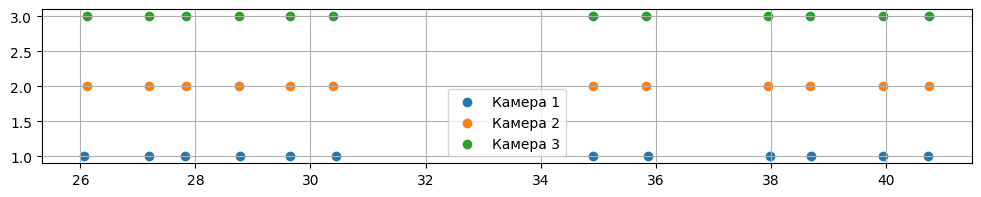

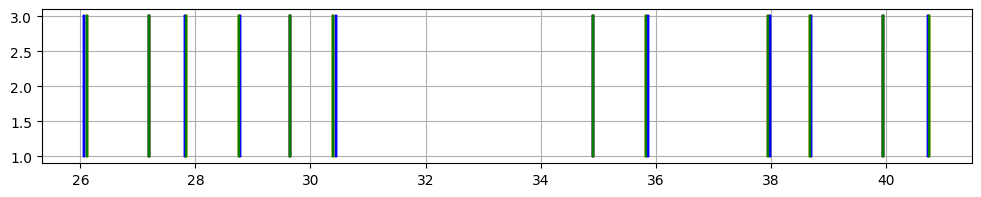

In [144]:
x = np.ones(12)
seq1 = np.array(frames_id1) - 246
seq2 = np.array(frames_id2) + 0
seq3 = np.array(frames_id3) + 0

plt.figure(figsize=(12, 2))
plt.scatter(seq1/23.98, x*1, label='Камера 1') 
plt.scatter(seq2/25, x*2, label='Камера 2')
plt.scatter(seq3/25, x*3, label='Камера 3')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 2))
for i in range(12):
    plt.plot([seq1/23.98]*2, [1,3], c='b')
    plt.plot([seq2/25]*2, [1,3], c='orange')
    plt.plot([seq3/25]*2, [1,3], c='g')
plt.grid()
plt.show()